# 1. Importing libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
import statsmodels.stats

# 2. Function definitions

In [2]:
def forecast_errors(actual, pred):
    '''Print forecast error measures.'''
    me = np.mean(pred - actual)
    mpe = 100 * np.mean((pred - actual) / actual)
    mae = np.mean(np.abs(pred - actual))
    mape = 100 * np.mean(np.abs((pred - actual) / actual))
    rmse = np.sqrt(np.mean((pred - actual) ** 2))
    rmspe = 100 * np.sqrt(np.mean(((pred - actual) / actual) ** 2))
    result = pd.DataFrame(
        {"ME": me,
         "MPE": mpe,
         "MAE": mae,
         "MAPE": mape,
         "RMSE": rmse,
         "RMSPE": rmspe},
         index=[0]
    )
    return result

def plot_forecast(data, fitted, forecast, title=None):
    '''Plot a time series and forecast.'''
    plot_data = pd.concat([data, fitted, forecast], axis=1).reset_index(drop=False)
    plot_data.columns = ["date", "Actual", "Fitted", "Forecast"]
    plot_data = pd.melt(plot_data, id_vars=["date"])

    sns.set_style("whitegrid")
    sns.lineplot(plot_data, x="date", y="value", hue="variable")
    plt.title(title)
    plt.xlabel("Data")
    plt.ylabel(None)
    plt.show()

def run_entry_tests(data):
    variables = []
    seasonalities = []

    for df in data:
        for col in df.columns:
            variables.append(col)
            adf = tsa.adfuller(df[:, col])
            lb = statsmodels.stats.diagnostic.acorr_ljungbox(df[:, col])
            chow = statsmodels.stats.diagnostic
            

# 3. Importing data

In [3]:
monthly_data = pd.read_excel("dane.xlsx", sheet_name="miesięczne", parse_dates=["data"], index_col="data")
quarterly_data = pd.read_excel("dane.xlsx", sheet_name="kwartalne", parse_dates=["data"], index_col="data")
yearly_data = pd.read_excel("dane.xlsx", sheet_name="roczne", parse_dates=["data"], index_col="data")

print(monthly_data.info())
print(quarterly_data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 2012-01-01 to 2025-12-01
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pas_liczba      168 non-null    float64
 1   pas_prac_przew  168 non-null    float64
 2   pas_prac_eksp   168 non-null    float64
 3   tow_masa        168 non-null    float64
 4   tow_prac_przew  168 non-null    float64
 5   tow_prac_eksp   168 non-null    float64
dtypes: float64(6)
memory usage: 9.2 KB
None
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 64 entries, 2010-01-01 to 2025-10-01
Data columns (total 4 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   zarejestrowane samochody osobowe [szt.]      63 non-null     float64
 1   zarejestrowane samochody ciężarowe [szt.]    63 non-null     float64
 2   zarejestrowane ciągniki siodłowe [szt.]      63 n

In [4]:
print(yearly_data.info())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 37 entries, 1988-01-01 to 2024-01-01
Data columns (total 16 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   linie kolejowe eksploatowane [km]                                               26 non-null     float64
 1   linie kolejowe normalnotorowe ogółem [km]                                       26 non-null     float64
 2   linie kolejowe normalnotorowe zelektryfikowane [km]                             26 non-null     float64
 3   linie kolejowe normalnotorowe dwu- i więcej torowe [km]                         26 non-null     float64
 4   drogi ekspresowe [km]                                                           24 non-null     float64
 5   autostrady [km]                                                                 24 non-null     float64
 6   

# 4. Forecasting

In [5]:
pas_liczba = monthly_data["pas_liczba"].asfreq("MS")
pas_liczba.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 168 entries, 2012-01-01 to 2025-12-01
Freq: MS
Series name: pas_liczba
Non-Null Count  Dtype  
--------------  -----  
168 non-null    float64
dtypes: float64(1)
memory usage: 2.6 KB


In [6]:
print(pas_liczba.info())
train_pas_liczba = pas_liczba[:132]
test_pas_liczba = pas_liczba[132:]

print(train_pas_liczba.info())
print(test_pas_liczba.info())


<class 'pandas.core.series.Series'>
DatetimeIndex: 168 entries, 2012-01-01 to 2025-12-01
Freq: MS
Series name: pas_liczba
Non-Null Count  Dtype  
--------------  -----  
168 non-null    float64
dtypes: float64(1)
memory usage: 2.6 KB
None
<class 'pandas.core.series.Series'>
DatetimeIndex: 132 entries, 2012-01-01 to 2022-12-01
Freq: MS
Series name: pas_liczba
Non-Null Count  Dtype  
--------------  -----  
132 non-null    float64
dtypes: float64(1)
memory usage: 2.1 KB
None
<class 'pandas.core.series.Series'>
DatetimeIndex: 36 entries, 2023-01-01 to 2025-12-01
Freq: MS
Series name: pas_liczba
Non-Null Count  Dtype  
--------------  -----  
36 non-null     float64
dtypes: float64(1)
memory usage: 576.0 bytes
None


In [7]:
# ETS

ets_pas_liczba_model = tsa.ETSModel(train_pas_liczba, error="mul", trend="mul", seasonal="add", seasonal_periods=12)
ets_pas_liczba = ets_pas_liczba_model.fit()

fit_ets_pas_liczba = ets_pas_liczba.predict()
fc_ets_pas_liczba = ets_pas_liczba.predict("2023", "2025-12")

print(forecast_errors(train_pas_liczba, fit_ets_pas_liczba))
print(forecast_errors(test_pas_liczba, fc_ets_pas_liczba))


         ME       MPE       MAE      MAPE      RMSE      RMSPE
0  0.093573  1.422033  1.302788  6.838223  1.989749  16.874943
         ME       MPE       MAE      MAPE      RMSE     RMSPE
0  0.459236  1.423521  1.253498  3.735526  1.491887  4.471827


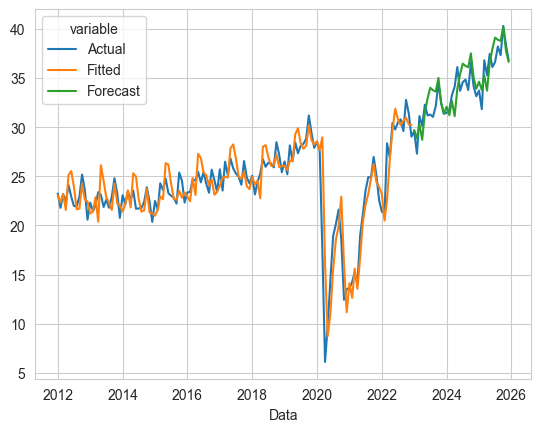

In [8]:
plot_forecast(pas_liczba, fit_ets_pas_liczba,fc_ets_pas_liczba)

In [9]:
print(tsa.adfuller(pas_liczba)[1])
print(tsa.adfuller(pas_liczba.diff(12).dropna())[1])

0.6875838235671423
0.006052624809420102


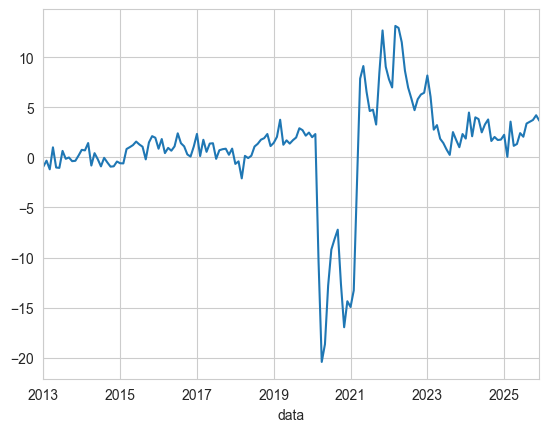

In [10]:
pas_liczba.diff(12).dropna().plot()
plt.show()

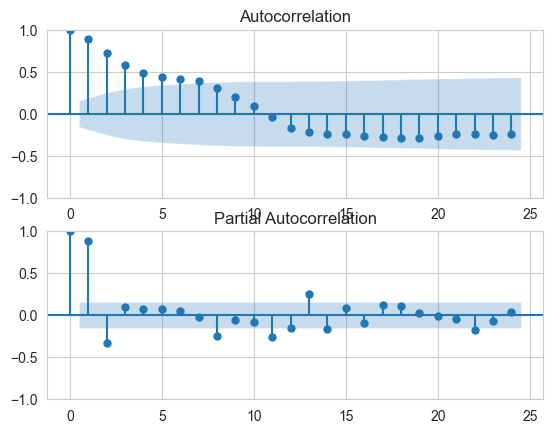

In [11]:
fig, ax = plt.subplots(2, 1)
tsa.graphics.plot_acf(pas_liczba.diff(12).dropna(), ax=ax[0], lags=24, alpha=0.05)
tsa.graphics.plot_pacf(pas_liczba.diff(12).dropna(), ax=ax[1], lags=24, alpha=0.05)
plt.show()

         ME       MPE       MAE     MAPE      RMSE      RMSPE
0 -0.130744  0.381129  1.054748  6.21137  1.766234  18.381876
         ME       MPE      MAE      MAPE     RMSE     RMSPE
0 -0.030802 -0.020703  0.77725  2.320749  1.02476  3.047408
                                      SARIMAX Results                                       
Dep. Variable:                           pas_liczba   No. Observations:                  168
Model:             SARIMAX(0, 1, 0)x(1, 1, [1], 12)   Log Likelihood                -298.823
Date:                              Wed, 25 Mar 2026   AIC                            605.647
Time:                                      11:55:02   BIC                            617.820
Sample:                                  01-01-2012   HQIC                           610.591
                                       - 12-01-2025                                         
Covariance Type:                                opg                                         
            

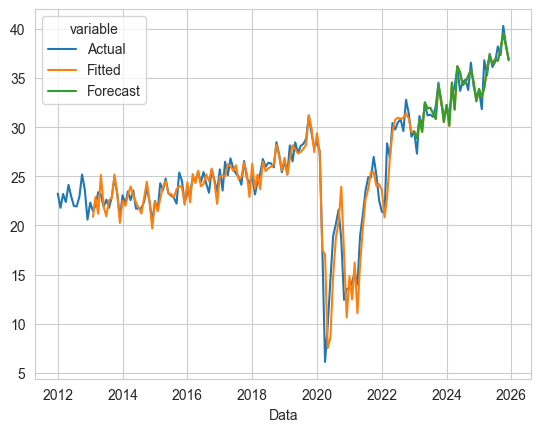

In [12]:
# ARIMA

dummy_pas_liczba = pd.Series(np.zeros(len(pas_liczba)), index=pas_liczba.index)
dummy_pas_liczba["2020-03":] = 1

#arima_pas_liczba_model = tsa.statespace.SARIMAX(pas_liczba, order=(1, 0, 0), seasonal_order=(0, 1, 1, 12))
arima_pas_liczba_model = tsa.statespace.SARIMAX(pas_liczba, dummy_pas_liczba, order=(0, 1, 0), seasonal_order=(1, 1, 1, 12))
#tsa.ARIMA(pas_liczba, order=(1, 0, 0), seasonal_order=(0, 1, 1, 12))
arima_pas_liczba = arima_pas_liczba_model.fit()

fit_arima_pas_liczba = arima_pas_liczba.predict()
fit_arima_pas_liczba.iloc[:13] = np.nan
fc_arima_pas_liczba = arima_pas_liczba.predict("2023", "2025-12")

print(forecast_errors(train_pas_liczba, fit_arima_pas_liczba))
print(forecast_errors(test_pas_liczba, fc_arima_pas_liczba))

print(arima_pas_liczba.summary())

plot_forecast(pas_liczba, fit_arima_pas_liczba, fc_arima_pas_liczba)

            wydatki inwestycyjne na infrastrukturę kolejową w cenach stałych [euro]
data                                                                               
1998-01-01                                        505032711.8                      
1999-01-01                                        360788067.1                      
2000-01-01                                        269565028.8                      
2001-01-01                                        136523655.7                      
2002-01-01                                        135057450.3                      
2003-01-01                                        274131011.7                      
2004-01-01                                        304633047.1                      
            wydatki inwestycyjne na infrastrukturę kolejową w cenach stałych [euro]
data                                                                               
2005-01-01                                       2.828507e+08               

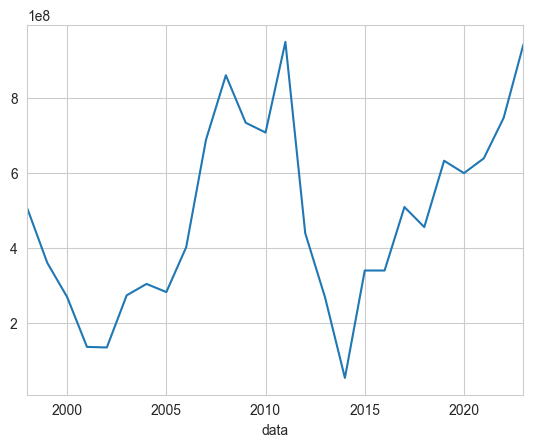

                                                       OLS Regression Results                                                      
Dep. Variable:     wydatki inwestycyjne na infrastrukturę kolejową w cenach stałych [euro]   R-squared:                       0.297
Model:                                                                                 OLS   Adj. R-squared:                  0.156
Method:                                                                      Least Squares   F-statistic:                     2.111
Date:                                                                     Wed, 25 Mar 2026   Prob (F-statistic):              0.206
Time:                                                                             12:16:12   Log-Likelihood:                -138.87
No. Observations:                                                                        7   AIC:                             281.7
Df Residuals:                                                               

c:\Users\Parte\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
c:\Users\Parte\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=19 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [34]:
period1 = yearly_data[["wydatki inwestycyjne na infrastrukturę kolejową w cenach stałych [euro]"]].loc[:"2004", :].dropna()
period2 = yearly_data[["wydatki inwestycyjne na infrastrukturę kolejową w cenach stałych [euro]"]].loc["2005":, :].dropna()

print(period1)
print(period2)

yearly_data["wydatki inwestycyjne na infrastrukturę kolejową w cenach stałych [euro]"].dropna().plot()
plt.show()

trend1 = pd.DataFrame(range(1, len(period1) + 1), index=period1.index, columns=["t"])
trend2 = pd.DataFrame(range(len(period1) + 1, len(period1) + 20), index=period2.index, columns=["t"])

trend1 = sm.add_constant(trend1)
trend2 = sm.add_constant(trend2)

OLSmodel1 = sm.OLS(period1, trend1)
OLSmodel2 = sm.OLS(period2, trend2)

OLSresults1 = OLSmodel1.fit()
OLSresults2 = OLSmodel2.fit()

print(OLSresults1.summary())
print(OLSresults2.summary())
